In [1]:
# Import Tensorflow & Pathlib librairies
import tensorflow as tf
import pathlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import os
import io
import warnings
from sklearn.model_selection import train_test_split
warnings.filterwarnings('ignore')

import en_core_web_sm
from spacy.lang.fr.stop_words import STOP_WORDS
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense


In [60]:


dataset = pd.read_csv("https://full-stack-bigdata-datasets.s3.eu-west-3.amazonaws.com/Deep+Learning/project/spam.csv", on_bad_lines='skip', encoding="latin-1")
dataset.head(20)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
5,spam,FreeMsg Hey there darling it's been 3 week's n...,NaN,NaN,NaN
6,ham,Even my brother is not like to speak with me. ...,NaN,NaN,NaN
7,ham,As per your request 'Melle Melle (Oru Minnamin...,NaN,NaN,NaN
8,spam,WINNER!! As a valued network customer you have...,NaN,NaN,NaN
9,spam,Had your mobile 11 months or more? U R entitle...,NaN,NaN,NaN


In [61]:
dataset.shape


(5572, 5)


**Surprising** : the 3 last columns has most 'Nan' values...let's examine the number of filled values of each columnn   


In [62]:
MissingValue = dataset.notna().sum()

print(MissingValue)



v1            5572
v2            5572
Unnamed: 2      50
Unnamed: 3      12
Unnamed: 4       6
dtype: int64


In [63]:
#Lets analyse first the precised values in the last colums

Precision = dataset [dataset["Unnamed: 2"].notna() | dataset["Unnamed: 3"].notna() | dataset["Unnamed: 4"].notna()]

Precision.head(80)


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
95,spam,Your free ringtone is waiting to be collected....,PO Box 5249,"MK17 92H. 450Ppw 16""",NaN
281,ham,\Wen u miss someone,the person is definitely special for u..... B...,why to miss them,"just Keep-in-touch\"" gdeve.."""
444,ham,\HEY HEY WERETHE MONKEESPEOPLE SAY WE MONKEYAR...,HOWU DOIN? FOUNDURSELF A JOBYET SAUSAGE?LOVE ...,NaN,NaN
671,spam,SMS. ac sun0819 posts HELLO:\You seem cool,"wanted to say hi. HI!!!\"" Stop? Send STOP to ...",NaN,NaN
710,ham,Height of Confidence: All the Aeronautics prof...,"this wont even start........ Datz confidence..""",NaN,NaN
899,spam,Your free ringtone is waiting to be collected....,PO Box 5249,"MK17 92H. 450Ppw 16""",NaN
1038,ham,"Edison has rightly said, \A fool can ask more ...",GN,GE,"GNT:-)"""
1127,ham,"Height of \Oh shit....!!\"" situation: A guy th...",".;-):-D""",NaN,NaN
1266,ham,\Hey sorry I didntgive ya a a bellearlier hunny,just been in bedbut mite go 2 thepub l8tr if u...,NaN,NaN
1384,ham,"Storming msg: Wen u lift d phne, u say \HELLO\...","bt not his girlfrnd... G o o d n i g h t . . .@""",NaN,NaN


In [64]:
#It appears that the filled-in rows correspond either to additions following the main message, or to references such as P.O. boxes, locations, or other types of information.
#So we can concatenate them with the main message
cols_to_concat = ["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"]
dataset[cols_to_concat] = dataset[cols_to_concat].fillna('')

# We create a new column by concatenating Col1 with all non-empty values from Col2, Col3, and Col4
dataset["Text"] = dataset["v2"] + " " + dataset[cols_to_concat].agg(' '.join, axis=1)

# we can also remove duplicate spaces.
dataset["Text"] = dataset["Text"].str.replace(r'\s+', ' ', regex=True).str.strip()

dataset


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4,Text
0,ham,"Go until jurong point, crazy.. Available only ...",,,,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...,,,,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,,,,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...,,,,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro...",,,,"Nah I don't think he goes to usf, he lives aro..."
...,...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,,,,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?,,,,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s...",,,,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...,,,,The guy did some bitching but I acted like i'd...


These 3 columns can be dropped and the first one renamed

In [65]:
dataset = dataset.drop(dataset.columns[[1, 2, 3, 4]], axis=1)
dataset = dataset.rename(columns={'v1': 'Target'})

display(dataset)

,Target,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


PART EDA

In [66]:
print("Number of duplicate rows: ",dataset.duplicated().sum())

Number of duplicate rows:  414


In [67]:
dataset= dataset.drop_duplicates()
dataset.shape

(5158, 2)

Target
ham     4516
spam     642
Name: count, dtype: int64


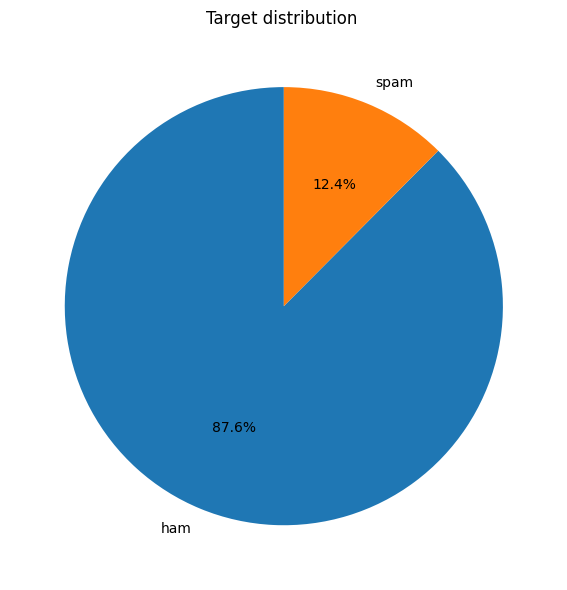

The dataset is quite imbalanced


In [68]:
df=dataset['Target'].value_counts()
print(df)



# Spam distribution

labels = df.index.tolist() # creates a list of labels (0 and 1)
sizes = df.values.tolist() # creates a list of the 0 and 1 counts
# Pie chart
plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title("Target distribution ")
# Display the plot
plt.tight_layout()
plt.show()
print("The dataset is quite imbalanced")

In [69]:
#length of the text for ham and spam

dataset["text_length"] = dataset["Text"].apply(len)

fig = px.histogram(dataset, "text_length", color="Target", barmode="overlay")
fig.show()


Most **spam** messages are between **135 and 160** characters long.<br>

Most **ham** messages are between **20 and 40** characters long.

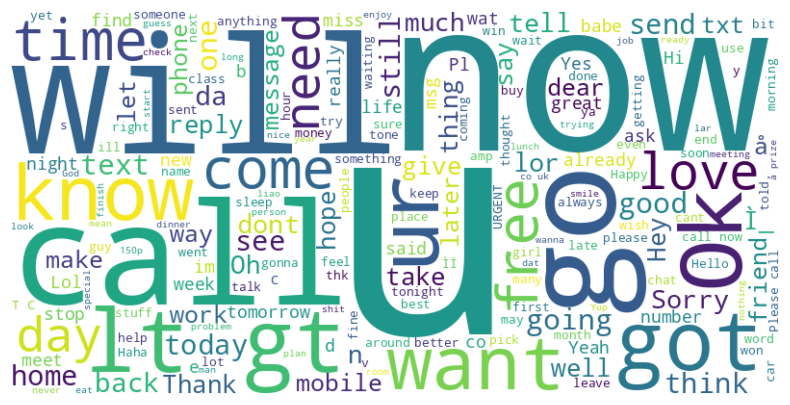

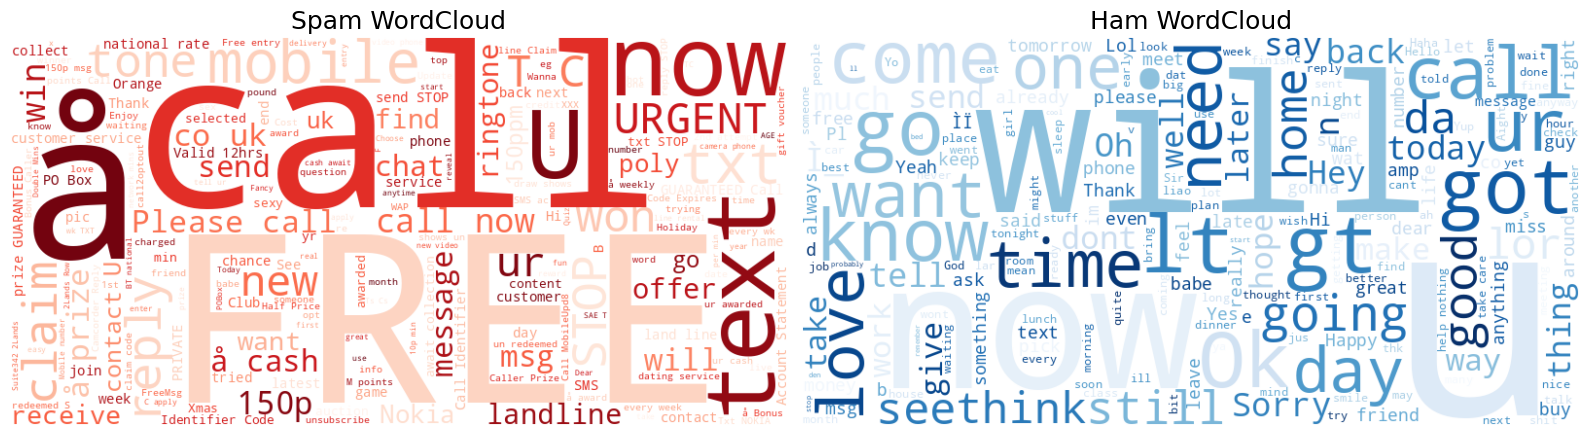

In [12]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Display the worldcloud for the whole datframe
wd = WordCloud(width=800, height=400, background_color='white')
cloud = wd.generate(' '.join(dataset['Text']))

#  Display the worldcloud
plt.figure(figsize=(10, 5))
plt.imshow(cloud, interpolation='bilinear')
plt.axis('off')
plt.show()



# Then we can crealoud for each target/ type of text
spam_text = ' '.join(dataset[dataset['Target'] == 'spam']['Text'])
ham_text = ' '.join(dataset[dataset['Target'] == 'ham']['Text'])


spam_wc = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(spam_text)
ham_wc = WordCloud(width=800, height=400, background_color='white', colormap='Blues').generate(ham_text)


plt.figure(figsize=(16, 8))

plt.subplot(1, 2, 1)
plt.imshow(spam_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Spam WordCloud', fontsize=18)

plt.subplot(1, 2, 2)
plt.imshow(ham_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Ham WordCloud', fontsize=18)

plt.tight_layout()
plt.show()







By comparing each specific word cloud with the global one, we can observe that the most frequent words differ between the two types of messages — this reflects the fact that they serve different purposes.<br>

We also notice that the global word cloud contains many more words from ham messages, which can be explained by the imbalance in the number of spam and ham messages."



PREPROCESSING

In [70]:
!python -m spacy download en_core_web_sm -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 40.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [71]:
import en_core_web_sm
nlp = en_core_web_sm.load()

# Import Stop words
from spacy.lang.en.stop_words import STOP_WORDS

In [72]:

# Remove all non alphanumeric characters except whitespaces :
dataset["text_clean"] = dataset["Text"].apply(lambda x:''.join(ch for ch in x if ch.isalnum() or ch==" "))

# removing double spaces and spaces at the beginning and end of strings :
dataset["text_clean"] = dataset["text_clean"].apply(lambda x: x.replace(" +"," ").lower().strip())

# removing stop words and replacing every word with their lemma :
dataset["text_clean"] = dataset["text_clean"].apply(lambda x: " ".join([token.lemma_ for token in nlp(x) if (token.lemma_ not in STOP_WORDS) & (token.text not in STOP_WORDS)]))



In [73]:
dataset.head()


,Target,Text,text_length,text_clean
0,ham,"Go until jurong point, crazy.. Available only ...",111,jurong point crazy available bugis n great wor...
1,ham,Ok lar... Joking wif u oni...,29,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,free entry 2 wkly comp win fa cup final tkts 2...
3,ham,U dun say so early hor... U c already then say...,49,u dun early hor u c
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,nah think usf live


In [74]:
#TOKENIZE

tokenizer = tf.keras.preprocessing.text.Tokenizer(num_words=1000, oov_token="out_of_vocab") # instanciate the tokenizer
tokenizer.fit_on_texts(dataset["text_clean"])
dataset['text_tokenized'] = tokenizer.texts_to_sequences(dataset["text_clean"])


dataset['len_txt'] = dataset['text_tokenized'].apply(lambda x: len(x))
dataset = dataset[dataset["len_txt"]!=0]

# Labeling the target column :
dataset['Target_id'] = dataset['Target'].map({'ham':0,'spam':1})


In [75]:
dataset.head(100)

,Target,Text,text_length,text_clean,text_tokenized,len_txt,Target_id
0,ham,"Go until jurong point, crazy.. Available only ...",111,jurong point crazy available bugis n great wor...,"[1, 214, 411, 485, 853, 34, 55, 263, 854, 75, ...",14,0
1,ham,Ok lar... Joking wif u oni...,29,ok lar joking wif u oni,"[12, 174, 1, 264, 2, 1]",6,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,free entry 2 wkly comp win fa cup final tkts 2...,"[15, 335, 4, 708, 709, 45, 1, 985, 486, 1, 1, ...",22,1
3,ham,U dun say so early hor... U c already then say...,49,u dun early hor u c,"[2, 115, 137, 1, 2, 84]",6,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,nah think usf live,"[662, 22, 600, 154]",4,0
...,...,...,...,...,...,...,...
96,ham,Watching telugu movie..wat abt u?,33,watch telugu moviewat abt u,"[100, 1, 1, 275, 2]",5,0
97,ham,i see. When we finish we have loads of loans t...,51,finish load loan pay,"[94, 612, 718, 133]",4,0
98,ham,Hi. Wk been ok - on hols now! Yes on for a bit...,184,hi wk ok hol yes bit run forgot hairdresser ...,"[33, 302, 12, 1, 78, 145, 206, 1, 1, 1, 24, 26...",18,0
99,ham,Please don't text me anymore. I have nothing e...,57,text anymore,"[21, 773]",2,0


In [76]:
dataset.shape



(5141, 7)

In [77]:
#PADDING

# Apply padding to the tokenized text :
text_padded = tf.keras.preprocessing.sequence.pad_sequences(dataset["text_tokenized"], padding="post")

print(text_padded.shape)
text_padded



(5141, 72)


array([[  1, 214, 411, ...,   0,   0,   0],
       [ 12, 174,   1, ...,   0,   0,   0],
       [ 15, 335,   4, ...,   0,   0,   0],
       ...,
       [  1,   1,   1, ...,   0,   0,   0],
       [107,   1,   1, ...,   0,   0,   0],
       [  1, 344,   0, ...,   0,   0,   0]], dtype=int32)

In [78]:
# Train Test Split
X_temp, X_test, Y_temp, Y_test = train_test_split(text_padded, dataset['Target_id'], test_size=0.1, random_state=42, stratify=dataset['Target_id'])
X_train, X_val, Y_train, Y_val = train_test_split(X_temp, Y_temp, test_size=0.2, random_state=42, stratify=Y_temp)



In [79]:
# Now that your sequences are padded create the tensor dataset for the training, and validation set. The target variable is qualitative ordinal, this means you may treat the sentiment analysis problem as a regression problem.

train = tf.data.Dataset.from_tensor_slices((X_train, Y_train))
val = tf.data.Dataset.from_tensor_slices((X_val, Y_val))

# Shuffle and batch the datasets
batch_size = 64
train_batch = train.shuffle(buffer_size=len(train)).batch(batch_size)
val_batch = val.batch(batch_size)



# Look at a batch of data

for review, value in train_batch.take(1):
  print(review, value)





tf.Tensor(
[[974 340  11 ...   0   0   0]
 [453  25 493 ...   0   0   0]
 [ 12   1 204 ...   0   0   0]
 ...
 [  1   1  17 ...   0   0   0]
 [ 59  83   1 ...   0   0   0]
 [  1 829   0 ...   0   0   0]], shape=(64, 72), dtype=int32) tf.Tensor(
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0], shape=(64,), dtype=int64)


#  **Models** <br>
# We start first with a simple model : Embedding

In [23]:


vocab_size = tokenizer.num_words
embedding_dim= 128
model = Sequential([
                  Embedding(vocab_size+1, embedding_dim,input_shape=[review.shape[1],], name="embedding"), # +1 for the padding value 0
                  GlobalAveragePooling1D(),
                  Dense(64, activation='relu'),
                  Dense(32, activation='relu'),
                  Dense(8, activation='relu'),
                  Dense(1, activation="sigmoid")
                  ])

In [24]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 72, 128)           128128    
                                                                 
 global_average_pooling1d (  (None, 128)               0         
 GlobalAveragePooling1D)                                         
                                                                 
 dense (Dense)               (None, 64)                8256      
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dense_2 (Dense)             (None, 8)                 264       
                                                                 
 dense_3 (Dense)             (None, 1)                 9         
                                                        

In [25]:
# Compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

#Fitting the model

history = model.fit(train_batch,
                    epochs=50,
                    validation_data=val_batch)

Epoch 1/50
58/58 [==============================] - 2s 8ms/step - loss: 0.4732 - accuracy: 0.8751 - val_loss: 0.3441 - val_accuracy: 0.8747
Epoch 2/50
58/58 [==============================] - 0s 5ms/step - loss: 0.3273 - accuracy: 0.8751 - val_loss: 0.3042 - val_accuracy: 0.8747
Epoch 3/50
58/58 [==============================] - 0s 4ms/step - loss: 0.2532 - accuracy: 0.8751 - val_loss: 0.1848 - val_accuracy: 0.8747
Epoch 4/50
58/58 [==============================] - 0s 5ms/step - loss: 0.1637 - accuracy: 0.9143 - val_loss: 0.1438 - val_accuracy: 0.9644
Epoch 5/50
58/58 [==============================] - 0s 4ms/step - loss: 0.1136 - accuracy: 0.9686 - val_loss: 0.0820 - val_accuracy: 0.9698
Epoch 6/50
58/58 [==============================] - 0s 4ms/step - loss: 0.0632 - accuracy: 0.9795 - val_loss: 0.0614 - val_accuracy: 0.9773
Epoch 7/50
58/58 [==============================] - 0s 5ms/step - loss: 0.0462 - accuracy: 0.9846 - val_loss: 0.0672 - val_accuracy: 0.9795
Epoch 8/50
58/58 [==

In [26]:
print(history.history.keys())

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


In [27]:
# Evaluate the model
val_loss_simple, val_accuracy_simple =model.evaluate(val_batch)
print(f"Validation Loss: {val_loss_simple}")
print(f"Validation Accuracy: {val_accuracy_simple}")


15/15 [==============================] - 0s 3ms/step - loss: 0.0878 - accuracy: 0.9838
Validation Loss: 0.0878438949584961
Validation Accuracy: 0.9838013052940369


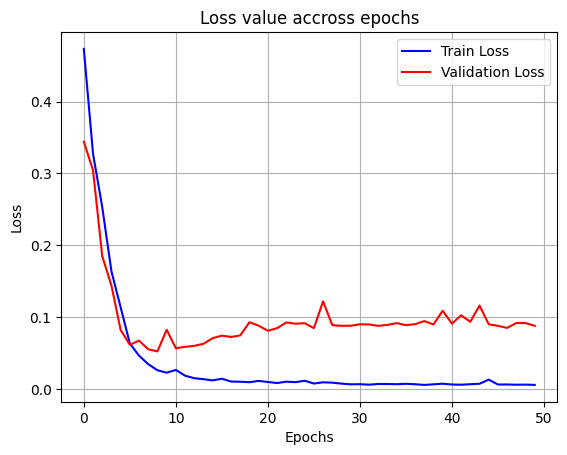

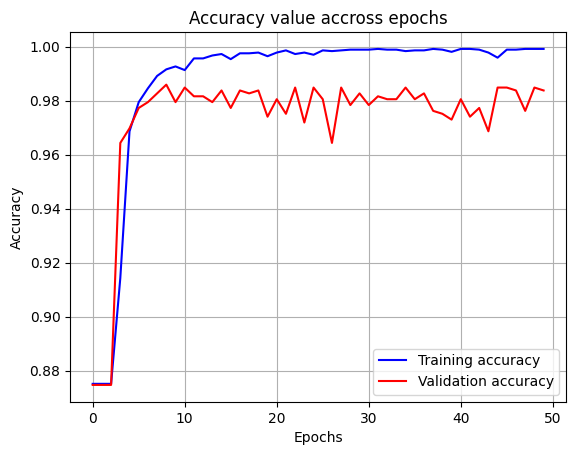

In [28]:
import matplotlib.pyplot as plt
#loss curves
plt.plot(history.history["loss"], label="Train Loss", color="blue")
plt.plot(history.history["val_loss"], label="Validation Loss", color="red")
plt.title("Loss value accross epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()



# accuracy curves
plt.plot(history.history["accuracy"], label="Training accuracy", color="blue")
plt.plot(history.history["val_accuracy"], label="Validation accuracy", color="red")
plt.title("Accuracy value accross epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()




In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

1/1 [==============================] - 0s 76ms/step
Confusion Matrix:
[[807   3]
 [ 12 104]]


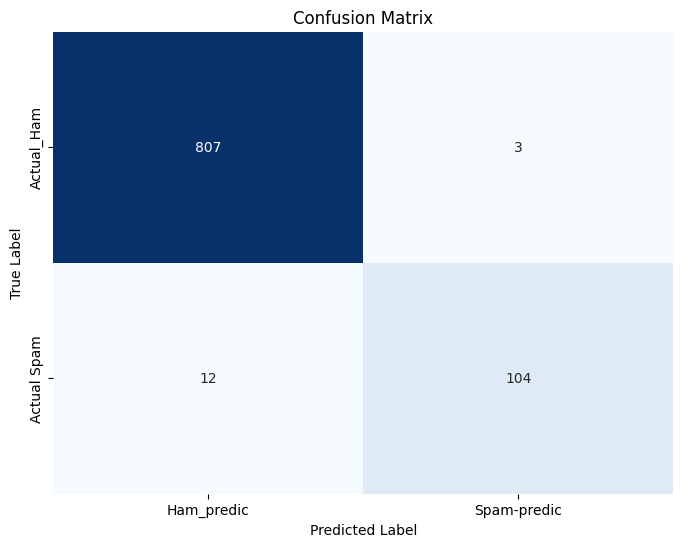


True Positives (TP): 104
True Negatives (TN): 807
False Positives (FP): 3
False Negatives (FN): 12
Accuracy: 0.9838
Precision: 0.9720
Recall: 0.8966
F1-Score: 0.9327


In [30]:

import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'model' is already trained from your provided code
# And 'val_batch' is your validation dataset (or you could use a separate test_batch)

# 1. Make Predictions on Your Validation/Test Data


#  collect all true labels and predictions
all_true_labels = []
all_predictions_prob = []

for reviews, labels in val_batch:
    predictions = model.predict(reviews)
    all_predictions_prob.extend(predictions.flatten()) # Flatten to a 1D list
    all_true_labels.extend(labels.numpy().flatten()) # Assuming labels are tf.Tensors, convert to numpy and flatten

# Convert lists to numpy arrays
all_true_labels = np.array(all_true_labels)
all_predictions_prob = np.array(all_predictions_prob)

# 2. Convert Probabilities to Class Labels
# For binary classification with sigmoid, typically 0.5 is the threshold
all_predicted_labels = (all_predictions_prob > 0.5).astype(int)

# 3. Create the Confusion Matrix
cm = confusion_matrix(all_true_labels, all_predicted_labels)
print("Confusion Matrix:")
print(cm)

# 4. Visualize the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Ham_predic', 'Spam-predic'],
            yticklabels=['Actual_Ham', 'Actual Spam'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# You can also calculate other metrics from the confusion matrix
# True Positives, True Negatives, False Positives, False Negatives
tn, fp, fn, tp = cm.ravel()

print(f"\nTrue Positives (TP): {tp}")
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")

# Further metrics (optional)
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1_score:.4f}")

In [31]:
# Evaluate the model
val_loss_simple, val_accuracy_simple =model.evaluate(val_batch)
print(f"Validation Loss: {val_loss_simple}")
print(f"Validation Accuracy: {val_accuracy_simple}")

15/15 [==============================] - 0s 3ms/step - loss: 0.0878 - accuracy: 0.9838
Validation Loss: 0.0878438949584961
Validation Accuracy: 0.9838013052940369


In [32]:
# saving the model :
model.save('/content/drive/MyDrive/FULLSTACK/PROJET/6. A&T SPAM Detector/spam_detector_modelEmbedding1.keras')

**Conclusion:**<br>
The model learns very quickly, achieving an accuracy of 0.87 at Epoch 1 and 0.97 (validation) by Epoch 5., similar to the loss behavior.

Subsequently, we observe a gradual increase in accuracy, reaching 0.9992 at Epoch 49 . Starting from around Epoch 10–12, the validation loss stops improving and begins to fluctuate or rise slightly, while training loss continues to decrease. <br>
**----> Limit 1** : This could indicate a start of overfitting, where the model begins to memorize the training data too closely.

*Matrice de confusion*:<br>
Through the confusion matrix, we note better prediction for HAMs, which can be explained by data imbalance, as observed in the data analysis section <br>
Recall pour Spam : 104 / (104 + 12) ≈ 0.897 <br>
Recall pour Ham : 807 / (807 + 3) ≈ 0.996

**----> Limit 2** This can be attributed to the class imbalance, where Ham messages are significantly more frequent than Spam in the dataset.
<br>
<br>
**Possible improvements :** <br>
We can now consider several avenues for improving our model:
- Add dropout layers after the Dense layers to reduce overfitting.
- Apply L2 regularization
- Implement early stopping to prevent the model from over-training.
- Adjust class weights during training to mitigate the effect of class imbalance.

 # Embedding with improvments

In [80]:
from tensorflow.keras.layers import Dropout

from tensorflow.keras.regularizers import l2

vocab_size = tokenizer.num_words
embedding_dim= 128
max_sequence_length = review.shape[1]

model_with_dropout = Sequential([
                  Embedding(vocab_size+1, embedding_dim,input_length=max_sequence_length, name="embedding"), # +1 for the padding value 0
                  GlobalAveragePooling1D(),
                  Dense(64, activation='relu', kernel_regularizer=l2(l2=0.001)), # Apply L2 regularization
                                                                  # 0.001 is a current value

                  Dense(32, activation='relu'),
                  Dropout(0.30),                 #apply dropout
                  Dense(8, activation='relu'),
                  Dropout(0.20),                 #apply lower dropout to prevent overfitting
                  Dense(1, activation="sigmoid")
                  ])



In [81]:
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils import class_weight
import numpy as n

# Défine the EarlyStopping

early_stopping_callback = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1 # Pour afficher quand l'entraînement s'arrête
)


# count number of each type of target
value_counts = dataset['Target_id'].value_counts()
display(value_counts)

# Create the class weight dictionary
# The weighting is calculated as follows:
# weight = (1 / count) * (total_count / 2)
# This gives more weight to the rare classes
class_weights = {}
total = value_counts.sum()

for class_id in value_counts.index:
    weight = (1 / value_counts[class_id]) * (total / 2)
    class_weights[class_id] = weight

print("Poids par classe :", class_weights)







,count
Target_id,
0,4499
1,642


Poids par classe : {0: 0.5713491887086019, 1: 4.003894080996885}


In [82]:


model_with_dropout.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# train the new modele with Early Stopping)
history_dropout = model_with_dropout.fit(train_batch,
                                        epochs=50,
                                        validation_data=val_batch,
                                        class_weight=class_weights,
                                        callbacks=[early_stopping_callback])

Epoch 1/50
58/58 [==============================] - 2s 11ms/step - loss: 0.7488 - accuracy: 0.5786 - val_loss: 0.7169 - val_accuracy: 0.9222
Epoch 2/50
58/58 [==============================] - 0s 6ms/step - loss: 0.6437 - accuracy: 0.7559 - val_loss: 0.4905 - val_accuracy: 0.9406
Epoch 3/50
58/58 [==============================] - 0s 6ms/step - loss: 0.3775 - accuracy: 0.8276 - val_loss: 0.2154 - val_accuracy: 0.9611
Epoch 4/50
58/58 [==============================] - 0s 5ms/step - loss: 0.2858 - accuracy: 0.8962 - val_loss: 0.2228 - val_accuracy: 0.9687
Epoch 5/50
58/58 [==============================] - 0s 8ms/step - loss: 0.2316 - accuracy: 0.9289 - val_loss: 0.1827 - val_accuracy: 0.9719
Epoch 6/50
58/58 [==============================] - 0s 5ms/step - loss: 0.1937 - accuracy: 0.9578 - val_loss: 0.1437 - val_accuracy: 0.9752
Epoch 7/50
58/58 [==============================] - 0s 5ms/step - loss: 0.1818 - accuracy: 0.9562 - val_loss: 0.1252 - val_accuracy: 0.9773
Epoch 8/50
58/58 [=

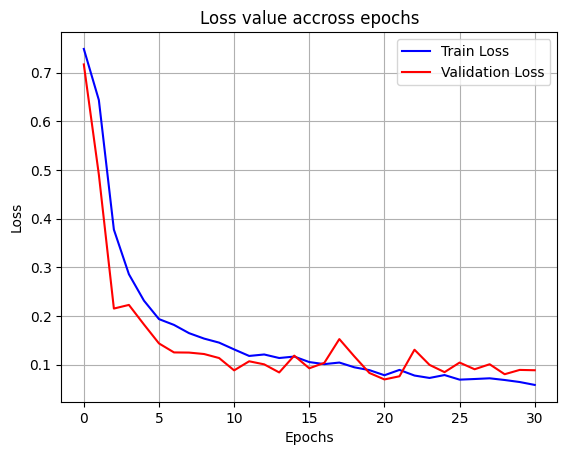

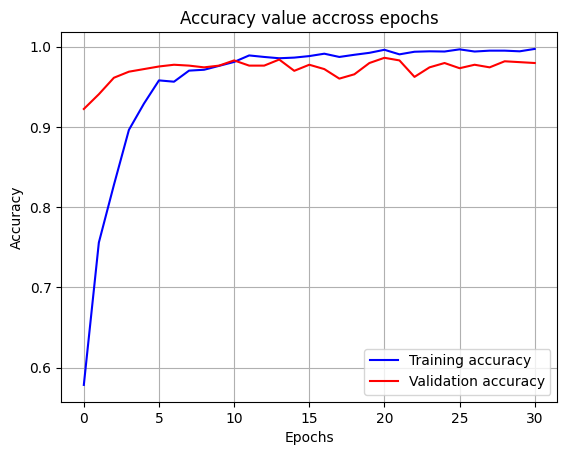

In [83]:
import matplotlib.pyplot as plt
# Loss curves
plt.plot(history_dropout.history["loss"], label="Train Loss", color="blue")
plt.plot(history_dropout.history["val_loss"], label="Validation Loss", color="red")
plt.title("Loss value accross epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()



# accuracy curves
plt.plot(history_dropout.history["accuracy"], label="Training accuracy", color="blue")
plt.plot(history_dropout.history["val_accuracy"], label="Validation accuracy", color="red")
plt.title("Accuracy value accross epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()




1/1 [==============================] - 0s 75ms/step
Confusion Matrix:
[[809   1]
 [ 12 104]]


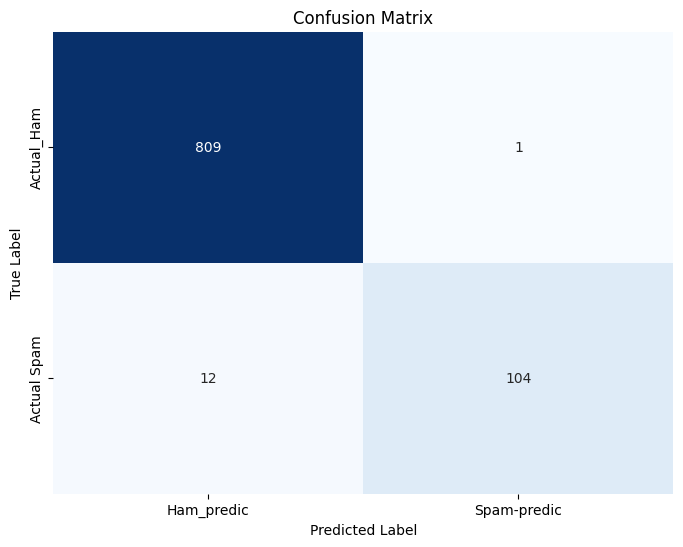


True Positives (TP): 104
True Negatives (TN): 809
False Positives (FP): 1
False Negatives (FN): 12
Accuracy: 0.9860
Precision: 0.9905
Recall: 0.8966
F1-Score: 0.9412


In [84]:

import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'model' is already trained from your provided code
# And 'val_batch' is your validation dataset (or you could use a separate test_batch)

# 1. Make Predictions on Your Validation/Test Data


#  collect all true labels and predictions
all_true_labels = []
all_predictions_prob = []

for reviews, labels in val_batch:
    predictions = model_with_dropout.predict(reviews)
    all_predictions_prob.extend(predictions.flatten()) # Flatten to a 1D list
    all_true_labels.extend(labels.numpy().flatten()) # Assuming labels are tf.Tensors, convert to numpy and flatten

# Convert lists to numpy arrays
all_true_labels = np.array(all_true_labels)
all_predictions_prob = np.array(all_predictions_prob)

# 2. Convert Probabilities to Class Labels
# For binary classification with sigmoid, typically 0.5 is the threshold
all_predicted_labels = (all_predictions_prob > 0.5).astype(int)

# 3. Create the Confusion Matrix
cm = confusion_matrix(all_true_labels, all_predicted_labels)
print("Confusion Matrix:")
print(cm)

# 4. Visualize the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Ham_predic', 'Spam-predic'],
            yticklabels=['Actual_Ham', 'Actual Spam'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# You can also calculate other metrics from the confusion matrix
# True Positives, True Negatives, False Positives, False Negatives
tn, fp, fn, tp = cm.ravel()

print(f"\nTrue Positives (TP): {tp}")
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")

# Further metrics (optional)
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1_score:.4f}")



In [85]:

# Evaluate the model
val_loss_dropout, val_accuracy_dropout =model_with_dropout.evaluate(val_batch)
print(f"Validation Loss: {val_loss_dropout}")
print(f"Validation Accuracy: {val_accuracy_dropout}")


15/15 [==============================] - 0s 2ms/step - loss: 0.0697 - accuracy: 0.9860
Validation Loss: 0.06974994391202927
Validation Accuracy: 0.9859611392021179


**Conclusion** : <br>
We do observe clear improvements:
 - *Execution time*: Thanks to EarlyStopping, the training process stopped early at epoch 31, retaining the best results from epoch 21, which significantly reduced training time.
 - Model generalization: The model does not show severe overfitting — although the validation loss increases slightly toward the end, it remains under control, largely due to EarlyStopping.
  - Performance metrics: <br>
Accuracy improved to 99% on the training set and 97% on the validation set.<br>
False positives decreased significantly (only 1 case).

However, false negatives remain unchanged — spam messages are still harder to detect, even after applying class weight rebalancing.<br>
→ To improve this, it would be ideal to increase the volume of spam data manually to balance the dataset further and help the model learn spam patterns better.<br>




Now we can test other models as GRU and BERT to see if the final convergence  is confirmed.<br>
Given these observations, it seems worthwhile to implement EarlyStopping on these models as well.

In [86]:
from tensorflow.keras.layers import  Bidirectional, GRU, Dropout
from tensorflow.keras.preprocessing.sequence import pad_sequences

#MODEL GRU

In [87]:
model_GRU = Sequential([
    Embedding(vocab_size, embedding_dim, input_shape=[review.shape[1],], name="embedding"),
    Bidirectional(GRU(64, return_sequences=True)),
    Bidirectional(GRU(32, return_sequences=False)),

    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])



In [88]:
model_GRU.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model_GRU.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 72, 128)           128000    
                                                                 
 bidirectional_2 (Bidirecti  (None, 72, 128)           74496     
 onal)                                                           
                                                                 
 bidirectional_3 (Bidirecti  (None, 64)                31104     
 onal)                                                           
                                                                 
 dense_15 (Dense)            (None, 32)                2080      
                                                                 
 dense_16 (Dense)            (None, 1)                 33        
                                                                 
Total params: 235713 (920.75 KB)
Trainable params: 235

In [89]:
history_GRU = model_GRU.fit(train_batch,epochs=50,
                    validation_data=val_batch,
                    callbacks=[early_stopping_callback])




Epoch 1/50
58/58 [==============================] - 42s 573ms/step - loss: 0.3170 - accuracy: 0.8889 - val_loss: 0.1014 - val_accuracy: 0.9600
Epoch 2/50
58/58 [==============================] - 16s 278ms/step - loss: 0.0709 - accuracy: 0.9778 - val_loss: 0.0574 - val_accuracy: 0.9816
Epoch 3/50
58/58 [==============================] - 15s 266ms/step - loss: 0.0377 - accuracy: 0.9884 - val_loss: 0.0571 - val_accuracy: 0.9849
Epoch 4/50
58/58 [==============================] - 17s 286ms/step - loss: 0.0261 - accuracy: 0.9932 - val_loss: 0.0687 - val_accuracy: 0.9860
Epoch 5/50
58/58 [==============================] - 15s 261ms/step - loss: 0.0176 - accuracy: 0.9951 - val_loss: 0.0676 - val_accuracy: 0.9795
Epoch 6/50
58/58 [==============================] - 16s 270ms/step - loss: 0.0138 - accuracy: 0.9968 - val_loss: 0.0734 - val_accuracy: 0.9849
Epoch 7/50
58/58 [==============================] - 15s 252ms/step - loss: 0.0088 - accuracy: 0.9986 - val_loss: 0.0858 - val_accuracy: 0.9827

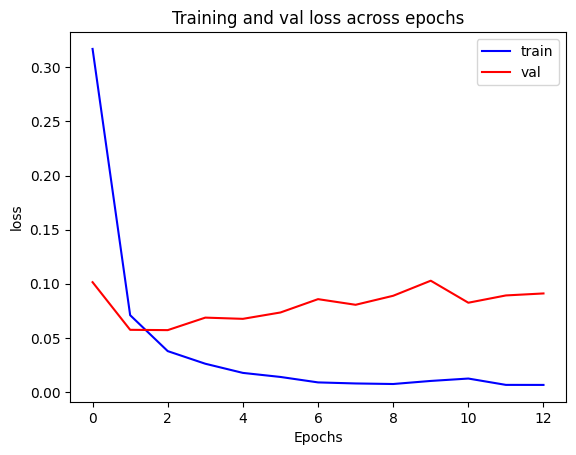

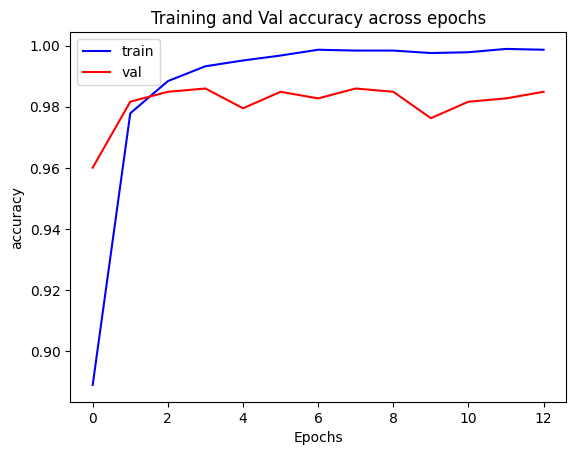

In [90]:
import matplotlib.pyplot as plt

# Visualization of the training process on the loss function
plt.plot(history_GRU.history["loss"], color="b")
plt.plot(history_GRU.history["val_loss"], color="r")
plt.ylabel("loss")
plt.xlabel("Epochs")
plt.legend(["train", "val"])
plt.title("Training and val loss across epochs")
plt.show()

plt.plot(history_GRU.history["accuracy"], color="b")
plt.plot(history_GRU.history["val_accuracy"], color="r")
plt.ylabel("accuracy")
plt.xlabel("Epochs")
plt.legend(["train", "val"])
plt.title("Training and Val accuracy across epochs")
plt.show()

In [91]:

# Evaluate the model
val_loss_GRU, val_accuracy_GRU =model_GRU.evaluate(val_batch)
print(f"Validation Loss: {val_loss_GRU}")
print(f"Validation Accuracy: {val_accuracy_GRU}")

15/15 [==============================] - 1s 60ms/step - loss: 0.0571 - accuracy: 0.9849
Validation Loss: 0.05711738020181656
Validation Accuracy: 0.9848812222480774


1/1 [==============================] - 2s 2s/step
Confusion Matrix:
[[808   2]
 [ 12 104]]


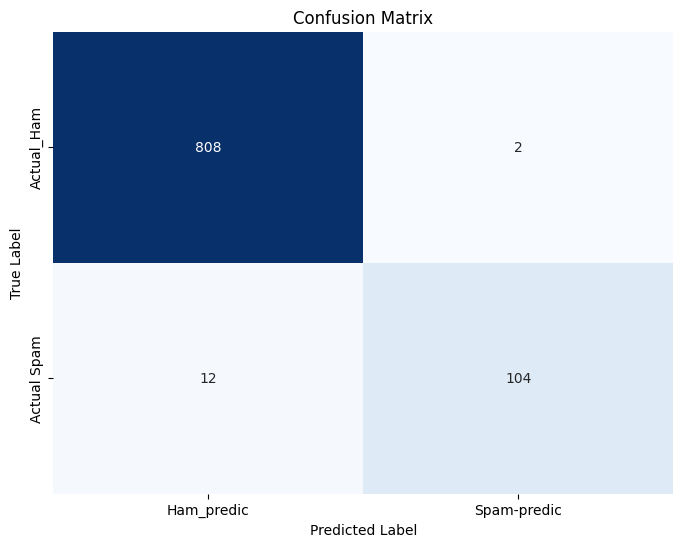


True Positives (TP): 104
True Negatives (TN): 808
False Positives (FP): 2
False Negatives (FN): 12
Accuracy: 0.9849
Precision: 0.9811
Recall: 0.8966
F1-Score: 0.9369


In [92]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'model' is already trained from your provided code
# And 'val_batch' is your validation dataset (or you could use a separate test_batch)

# 1. Make Predictions on Your Validation/Test Data


#  collect all true labels and predictions
all_true_labels = []
all_predictions_prob = []

for reviews, labels in val_batch:
    predictions = model_GRU.predict(reviews)
    all_predictions_prob.extend(predictions.flatten()) # Flatten to a 1D list
    all_true_labels.extend(labels.numpy().flatten()) # Assuming labels are tf.Tensors, convert to numpy and flatten

# Convert lists to numpy arrays
all_true_labels = np.array(all_true_labels)
all_predictions_prob = np.array(all_predictions_prob)

# 2. Convert Probabilities to Class Labels
# For binary classification with sigmoid, typically 0.5 is the threshold
all_predicted_labels = (all_predictions_prob > 0.5).astype(int)

# 3. Create the Confusion Matrix
cm = confusion_matrix(all_true_labels, all_predicted_labels)
print("Confusion Matrix:")
print(cm)

# 4. Visualize the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Ham_predic', 'Spam-predic'],
            yticklabels=['Actual_Ham', 'Actual Spam'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# You can also calculate other metrics from the confusion matrix
# True Positives, True Negatives, False Positives, False Negatives
tn, fp, fn, tp = cm.ravel()

print(f"\nTrue Positives (TP): {tp}")
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")

# Further metrics (optional)
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1_score:.4f}")



In [93]:
# saving the model :
model_GRU.save('/content/drive/MyDrive/FULLSTACK/PROJET/6. A&T SPAM Detector/spam_detector_modelGRU.keras')

#MODEL BERT


In [94]:
!pip install --upgrade tensorflow==2.15.0
!pip install --upgrade tensorflow_hub==0.15.0
!pip install --upgrade tensorflow_text==2.15.0

In [95]:
dataset.head()

,Target,Text,text_length,text_clean,text_tokenized,len_txt,Target_id
0,ham,"Go until jurong point, crazy.. Available only ...",111,jurong point crazy available bugis n great wor...,"[1, 214, 411, 485, 853, 34, 55, 263, 854, 75, ...",14,0
1,ham,Ok lar... Joking wif u oni...,29,ok lar joking wif u oni,"[12, 174, 1, 264, 2, 1]",6,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,free entry 2 wkly comp win fa cup final tkts 2...,"[15, 335, 4, 708, 709, 45, 1, 985, 486, 1, 1, ...",22,1
3,ham,U dun say so early hor... U c already then say...,49,u dun early hor u c,"[2, 115, 137, 1, 2, 84]",6,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,nah think usf live,"[662, 22, 600, 154]",4,0


In [96]:
# Train test split

# Train test split
X_train, X_val, y_train, y_val = train_test_split(dataset['text_clean'], dataset['Target_id'], test_size=0.3)

train = tf.data.Dataset.from_tensor_slices((X_train, y_train))
val = tf.data.Dataset.from_tensor_slices((X_val, y_val))

train_batch = train.shuffle(len(train)).batch(64)
val_batch = val.shuffle(len(val)).batch(64)


In [97]:
import tensorflow_hub as hub
import tensorflow_text

text_input = tf.keras.layers.Input(shape=(), dtype=tf.string)
preprocessor = hub.KerasLayer(
    "https://kaggle.com/models/tensorflow/bert/frameworks/TensorFlow2/variations/en-uncased-preprocess/versions/3")
encoder_inputs = preprocessor(text_input)
encoder = hub.KerasLayer(
    "https://www.kaggle.com/models/tensorflow/bert/frameworks/TensorFlow2/variations/bert-en-uncased-l-2-h-128-a-2/versions/2",
    trainable=False)
outputs = encoder(encoder_inputs)
pooled_output = outputs["pooled_output"]      # [batch_size, 768]
sequence_output = outputs["sequence_output"]  # [batch_size, seq_length, 768]

out = tf.keras.layers.Dropout(0.2,name='dropout')(pooled_output)
out = tf.keras.layers.Dense(16,activation='relu')(out)
out = tf.keras.layers.Dense(1,activation='sigmoid',name='output')(out)

model_bert=tf.keras.Model(inputs=[text_input],outputs=[out])

model_bert.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_bert = model_bert.fit(train_batch,
                    epochs=50,
                    validation_data=val_batch)

Epoch 1/50
57/57 [==============================] - 40s 545ms/step - loss: 0.3312 - accuracy: 0.8777 - val_loss: 0.2057 - val_accuracy: 0.9145
Epoch 2/50
57/57 [==============================] - 22s 387ms/step - loss: 0.1842 - accuracy: 0.9255 - val_loss: 0.1568 - val_accuracy: 0.9436
Epoch 3/50
57/57 [==============================] - 26s 461ms/step - loss: 0.1572 - accuracy: 0.9397 - val_loss: 0.1410 - val_accuracy: 0.9514
Epoch 4/50
57/57 [==============================] - 25s 437ms/step - loss: 0.1397 - accuracy: 0.9475 - val_loss: 0.1336 - val_accuracy: 0.9533
Epoch 5/50
57/57 [==============================] - 24s 416ms/step - loss: 0.1350 - accuracy: 0.9536 - val_loss: 0.1236 - val_accuracy: 0.9566
Epoch 6/50
57/57 [==============================] - 26s 454ms/step - loss: 0.1350 - accuracy: 0.9497 - val_loss: 0.1163 - val_accuracy: 0.9585
Epoch 7/50
57/57 [==============================] - 22s 395ms/step - loss: 0.1255 - accuracy: 0.9555 - val_loss: 0.1118 - val_accuracy: 0.9605

In [98]:
# saving the model :
model_bert.save('/content/drive/MyDrive/FULLSTACK/PROJET/6. A&T SPAM Detector/spam_detector_modelBert.keras')

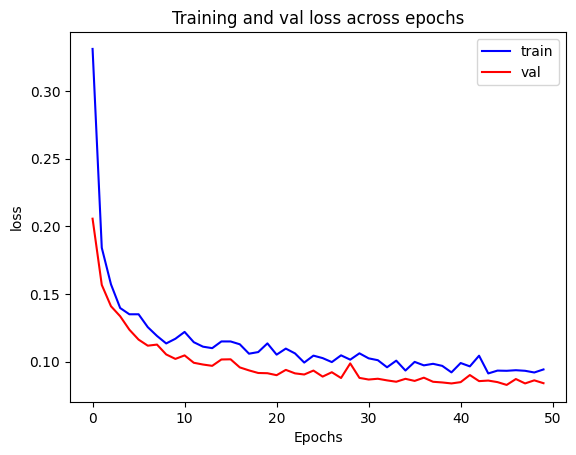

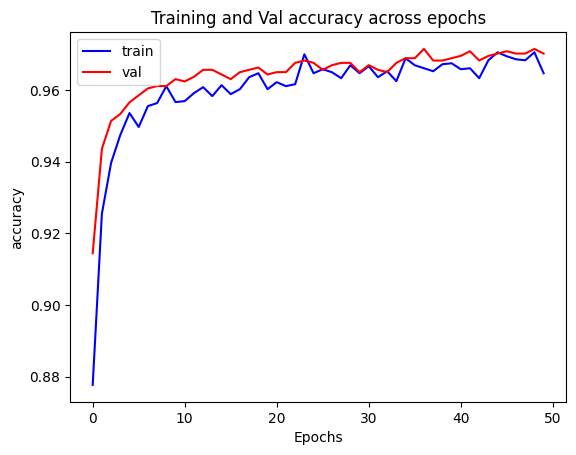

In [99]:
import matplotlib.pyplot as plt

# Loss curves
plt.plot(history_bert.history["loss"], color="b")
plt.plot(history_bert.history["val_loss"], color="r")
plt.ylabel("loss")
plt.xlabel("Epochs")
plt.legend(["train", "val"])
plt.title("Training and val loss across epochs")
plt.show()

plt.plot(history_bert.history["accuracy"], color="b")
plt.plot(history_bert.history["val_accuracy"], color="r")
plt.ylabel("accuracy")
plt.xlabel("Epochs")
plt.legend(["train", "val"])
plt.title("Training and Val accuracy across epochs")
plt.show()

In [100]:


val_loss_bert, val_accuracy_bert = model_bert.evaluate(val_batch)
print(f"Validation Loss: {val_loss_bert}")
print(f"Validation Accuracy: {val_accuracy_bert}")

25/25 [==============================] - 13s 522ms/step - loss: 0.0841 - accuracy: 0.9702
Validation Loss: 0.0840911790728569
Validation Accuracy: 0.9701879620552063


1/1 [==============================] - 0s 452ms/step
Confusion Matrix:
[[1344   16]
 [  30  153]]


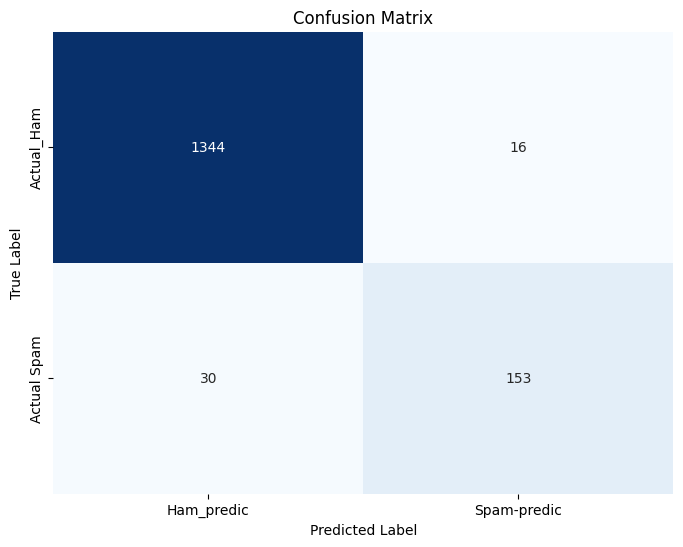


True Positives (TP): 153
True Negatives (TN): 1344
False Positives (FP): 16
False Negatives (FN): 30
Accuracy: 0.9702
Precision: 0.9053
Recall: 0.8361
F1-Score: 0.8693


In [101]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'model' is already trained from your provided code
# And 'val_batch' is your validation dataset (or you could use a separate test_batch)

# 1. Make Predictions on Your Validation/Test Data


#  collect all true labels and predictions
all_true_labels = []
all_predictions_prob = []

for reviews, labels in val_batch:
    predictions = model_bert.predict(reviews)
    all_predictions_prob.extend(predictions.flatten()) # Flatten to a 1D list
    all_true_labels.extend(labels.numpy().flatten()) # Assuming labels are tf.Tensors, convert to numpy and flatten

# Convert lists to numpy arrays
all_true_labels = np.array(all_true_labels)
all_predictions_prob = np.array(all_predictions_prob)

# 2. Convert Probabilities to Class Labels
# For binary classification with sigmoid, typically 0.5 is the threshold
all_predicted_labels = (all_predictions_prob > 0.5).astype(int)

# 3. Create the Confusion Matrix
cm = confusion_matrix(all_true_labels, all_predicted_labels)
print("Confusion Matrix:")
print(cm)

# 4. Visualize the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Ham_predic', 'Spam-predic'],
            yticklabels=['Actual_Ham', 'Actual Spam'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# You can also calculate other metrics from the confusion matrix
# True Positives, True Negatives, False Positives, False Negatives
tn, fp, fn, tp = cm.ravel()

print(f"\nTrue Positives (TP): {tp}")
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")

# Further metrics (optional)
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1_score:.4f}")



In [102]:
# Creating a DataFrame with the results
results = pd.DataFrame({'Simple embedding': [val_accuracy_simple, val_loss_simple],
                        'GRU model': [val_accuracy_GRU, val_loss_GRU],
                        'Bert model':[val_accuracy_bert,val_loss_bert],
                        'Improved Embedding': [val_accuracy_dropout,val_loss_dropout]})

results.T

,0,1
Simple embedding,0.983801,0.087844
GRU model,0.984881,0.057117
Bert model,0.970188,0.084091
Improved Embedding,0.985961,0.069750


##CONCLUSION : <br>
the **"Improved Embedding"** model is the superior choice, primarily due to its higher validation accuracy (val_accuracy).

While the GRU model exhibits a slightly lower loss, its increased complexity and the minimal difference in loss when compared to the "Improved Embedding" model make the **"Improved Embedding"** the preferred option. It offers a better balance of performance and simplicity.